## Imports:

In [ ]:
# if you don't have the libraries below installed, run this cell first.
# if you do have the libraries installed, you can skip this cell.

install.packages("lme4")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("MuMIn")
install.packages("lmtest")
install.packages("devtools")
#devtools::install_github("dustinfife/flexplot")

In [ ]:
library(lme4) # for building linear mixed effects models
library(ggplot2) # for plotting
library(tidyr) # for data manipulation and organization

# for model comparisons
library(MuMIn)
library(lmtest)

# a different library for model comparisons
#library(flexplot)

print("Done.")


Attaching package: 'flexplot'


The following object is masked from 'package:ggplot2':

    flip_data




[1] "Done."


## Load our dataframe:

https://o365coloradoedu-my.sharepoint.com/:f:/r/personal/some4995_colorado_edu/Documents/Music%20Algorithm%20Aversion%20project/Survey%20%26%20Behavioral%20Data?csf=1&web=1&e=Vj46KH

We will be working with: `Survey_data_condition_edit_1.csv`

In [2]:
df <- read.csv("C:/Users/sophi/Downloads/Survey_data_condition_edit_1.csv")

head(df) # view the first 6 rows of the dataframe

,Participant,Age,Music_importance,Musical_training,eBMRQ_factor,extraversion,agreeableness,conscientiousness,neuroticism,openness,music_condition,pleasure,beauty,interest,connectedness,valence,familiarity,pleasure_diff,connectedness_diff
,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,computer,81,84.0,92.5,43.0,86.5,0,-9,-6.5
2,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,peer,72,78.5,87.0,36.5,44.5,0,-9,-6.5
3,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,self-relevant,87,88.5,90.0,87.5,44.0,100,-9,-6.5
4,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,sensory-motor,93,74.5,91.5,29.5,83.5,100,-9,-6.5
5,0M3LDX,19,6,LOW,43.74,3.12,3.56,1.78,4.25,4.1,computer,65,56.0,75.5,33.0,52.0,0,-23,-5.5
6,0M3LDX,19,6,LOW,43.74,3.12,3.56,1.78,4.25,4.1,peer,42,57.5,40.0,27.5,47.5,0,-23,-5.5


Note the data type indicated underneath each column. Some columns that are supposed to be categorical or ordinal data are loaded as char/string data types (CHR)

We'll need to fix this manually before continuing.

In [3]:
df$Participant <- as.factor(df$Participant) # we want to redefine the participant column as nominal

# let's define music condition and musical training as ordinal, and specify a particular ranking
df$music_condition <- factor(df$music_condition, levels=c("self-relevant", "sensory-motor", "peer", "computer"), ordered=TRUE)
df$Musical_training <- factor(df$Musical_training, levels=c("LOW", "MED", "HIGH"), ordered=TRUE)

head(df)

,Participant,Age,Music_importance,Musical_training,eBMRQ_factor,extraversion,agreeableness,conscientiousness,neuroticism,openness,music_condition,pleasure,beauty,interest,connectedness,valence,familiarity,pleasure_diff,connectedness_diff
,<fct>,<int>,<int>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,computer,81,84.0,92.5,43.0,86.5,0,-9,-6.5
2,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,peer,72,78.5,87.0,36.5,44.5,0,-9,-6.5
3,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,self-relevant,87,88.5,90.0,87.5,44.0,100,-9,-6.5
4,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,sensory-motor,93,74.5,91.5,29.5,83.5,100,-9,-6.5
5,0M3LDX,19,6,LOW,43.74,3.12,3.56,1.78,4.25,4.1,computer,65,56.0,75.5,33.0,52.0,0,-23,-5.5
6,0M3LDX,19,6,LOW,43.74,3.12,3.56,1.78,4.25,4.1,peer,42,57.5,40.0,27.5,47.5,0,-23,-5.5


Some more sanity checks: we should only have one value here per participant (their "algorithm aversion" score).

Also, because the algorithm aversion score is a composite coming from both the computer and peer music conditions, the music conidtion label no longer makes sense. The raw rating columns are also no longer valid.

In [4]:
df <- df[df$music_condition == "computer",] # keep only one row per participant (let's just choose the computer row)
df <- subset(df, select = -c(music_condition, pleasure, beauty, interest, valence, connectedness, familiarity)) # clean up the columns that are no longer valid

head(df)

,Participant,Age,Music_importance,Musical_training,eBMRQ_factor,extraversion,agreeableness,conscientiousness,neuroticism,openness,pleasure_diff,connectedness_diff
,<fct>,<int>,<int>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,06ECDB,19,6,LOW,40.68,2.38,3.67,4.00,2.88,3.5,-9.0,-6.5
5,0M3LDX,19,6,LOW,43.74,3.12,3.56,1.78,4.25,4.1,-23.0,-5.5
9,1JVZTM,21,6,HIGH,42.52,1.50,4.33,5.00,2.25,4.5,29.5,42.0
13,1MM3K9,19,7,MED,61.06,3.75,4.11,4.00,2.75,4.1,5.5,14.0
17,1ZDS4P,20,6,MED,50.00,4.25,4.89,3.11,1.88,4.3,-8.0,-28.5
21,2IR3MC,23,7,HIGH,55.00,2.62,3.33,3.67,3.75,4.7,-21.5,-32.0


## Visualize and describe our variables of interest:

In [5]:
summary(df$pleasure_diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-42.000 -10.625   7.750   5.801  18.625  59.000       1 

Looking at the summary statistics for `pleasure_diff`, we see there is 1 missing value (NAs) in our dataframe. 

We should revisit the preprocessing script that produced this dataframe to determine why that is the case (is it a bug? is the participant's data truly missing?)

In [6]:
# for now, let's remove the NA rows from our dataframe so that they don't produce errors later
print(paste("Dataframe has ", nrow(df), " rows."))

df_cleaned <- drop_na(df)

print(paste("Dataframe has ", nrow(df_cleaned), " rows after dropping NAs."))


[1] "Dataframe has  109  rows."
[1] "Dataframe has  108  rows after dropping NAs."


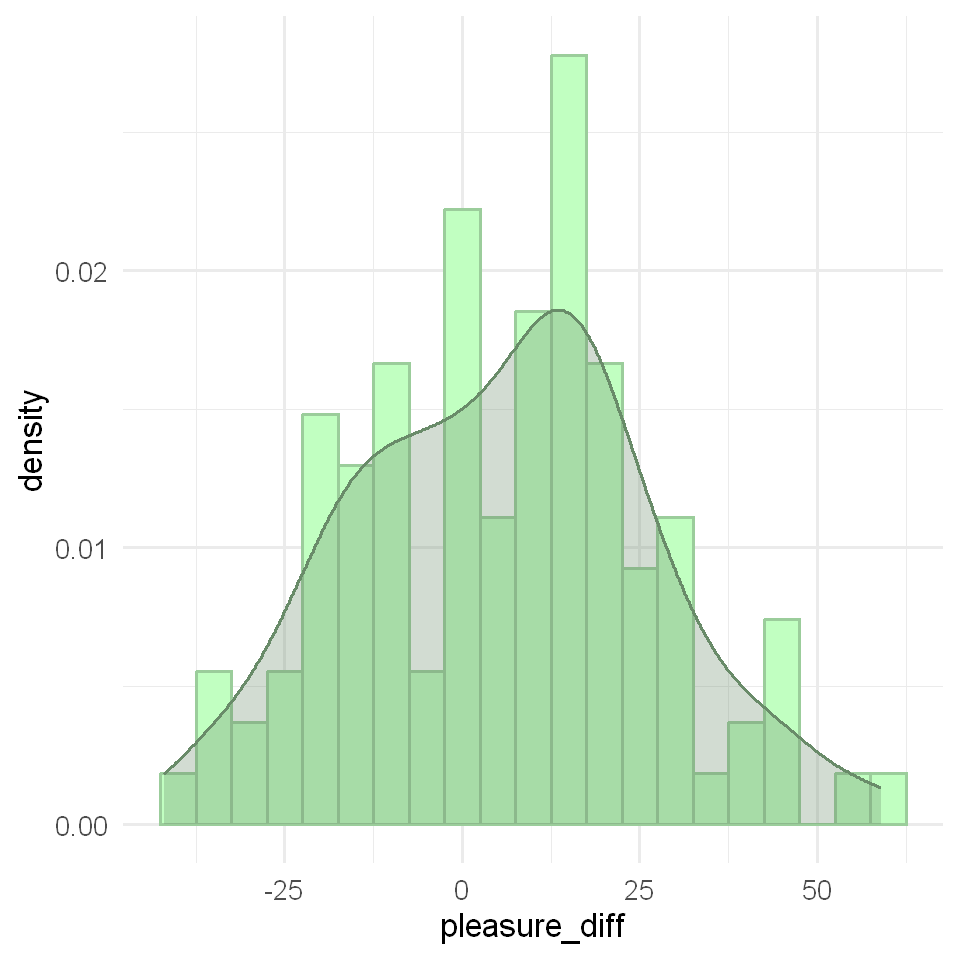

In [66]:
# visualize the distribution of our dependent variable
options(repr.plot.width=8, repr.plot.height=8)

ggplot(df_cleaned, aes(x=pleasure_diff)) +
       geom_histogram(aes(y=after_stat(density)), binwidth = 5, color = "darkseagreen3", fill= "darkseagreen1") +
       geom_density(alpha=0.3, color="darkseagreen4", linewidth=1, fill="darkseagreen4") +
       labs(x="pleasure_diff", y="density") +
       theme_minimal(base_size=20)

## Build and inspect a model:

If we need random effects or cluster variables, then we should use the function `lmer()` to build the model.

If we do not have random effects or cluster variables, then we can use the function `lm()` to build the model.

In [8]:
f1 <- lm(pleasure_diff ~ extraversion + Musical_training + Musical_training*extraversion, data=df_cleaned)

In [9]:
summary(f1)


Call:
lm(formula = pleasure_diff ~ extraversion + Musical_training + 
    Musical_training * extraversion, data = df_cleaned)

Residuals:
    Min      1Q  Median      3Q     Max 
-43.921 -12.928   0.618  12.415  64.068 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)  
(Intercept)                       10.704      7.579   1.412   0.1609  
extraversion                      -1.443      2.244  -0.643   0.5218  
Musical_training.L                28.846     13.932   2.071   0.0409 *
Musical_training.Q               -22.376     12.270  -1.824   0.0711 .
extraversion:Musical_training.L   -9.516      4.149  -2.294   0.0239 *
extraversion:Musical_training.Q    6.772      3.607   1.877   0.0633 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 20.48 on 102 degrees of freedom
Multiple R-squared:  0.08946,	Adjusted R-squared:  0.04483 
F-statistic: 2.004 on 5 and 102 DF,  p-value: 0.08425


## Model comparison:

More predictors, or terms, added to our model might help explain more of the variance in the dependent variable. But it will also add complexity to the model. How do we know that the extra terms we are adding to our models are "worth it"? 

In [47]:
f0 <- lm(pleasure_diff ~ 1, data=df_cleaned) #this is the "base" or "null" model. it only contains the y intercept term.
f1 <- lm(pleasure_diff ~ extraversion, data=df_cleaned)
f2 <- lm(pleasure_diff ~ Musical_training, data=df_cleaned)
f3 <- lm(pleasure_diff ~ extraversion + Musical_training, data=df_cleaned)
f4 <- lm(pleasure_diff ~ extraversion + Musical_training + extraversion*Musical_training, data=df_cleaned)

model.sel(f0, f1, f2, f3, f4, rank=AIC) # can also do rank=BIC

,(Intercept),extraversion,Musical_training,extraversion:Musical_training,df,logLik,AIC,delta,weight
,<dbl>,<dbl>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<mdl.wght>
f4,10.703611,-1.442841,+,+,7,-476.2392,966.4784,0.0000000,0.32997196
f0,5.800926,NA,NA,NA,2,-481.3002,966.6004,0.1220085,0.31044397
f1,15.261641,-2.892284,NA,NA,3,-480.4422,966.8845,0.4060320,0.26934463
f2,5.771942,NA,+,NA,4,-481.1569,970.3139,3.8354312,0.04848682
f3,15.171541,-2.878210,+,NA,5,-480.3065,970.6129,4.1344910,0.04175262


AIC and BIC are two commonly used metrics in model comparisons. Both of these metrics take into account how well the model fits the data, along with a penatly term for added complexity. For both AIC and BIC, lower values indicate the better model. But these two metrics are calculated differently.

Whether we use AIC or BIC usually depends on the purpose of the analysis. Sometimes people will look at both and compare. I encourage you to read about both of these metrics to understand how they are calculated and why we might use one over the other.

https://www.statswithr.com/foundational-statistics/using-aic-and-bic-for-model-comparisons

In [40]:
lrtest(f0, f4)

,#Df,LogLik,Df,Chisq,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2,-481.3002,NA,NA,NA
2,7,-476.2392,5,10.12201,0.07185109


LR-tests, or likelihood ration tests, compare two **NESTED** models to determine if adding the additional parameter made the model fit the data significantly better.

Models are considered "nested" if the smaller model is a subset of the larger model. For example:

`Y ~ 1`

`Y ~ X`

or

`Y ~ X`

`Y ~ X + Z`

are examples of nested models. But...

`Y ~ X`

`Y ~ Z`

or 

`Y ~ X`

`Y ~ R + Q`

are NOT nested models.

## Inspect model residuals:

All statistical tests have some sort of assumptions about the underlying data. If your data does not meet these assumptions, and you still report the results of the test, your results may not be valid.

Linear modeling and linear mixed modeling assumes, among other things, that the residuals of the model are normally distributed, and have equal variance.

https://www.statology.org/linear-regression-assumptions/

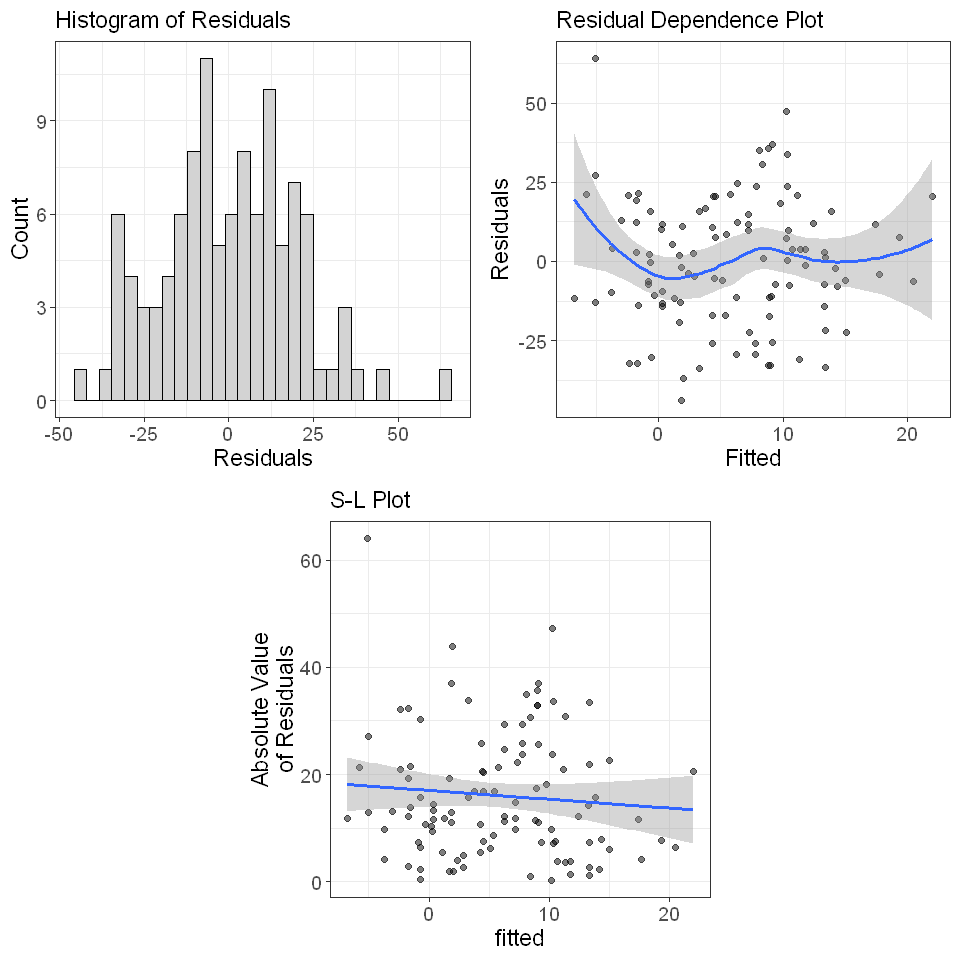

In [65]:
options(repr.plot.width=8, repr.plot.height=8)

visualize(f4, plot="residuals")

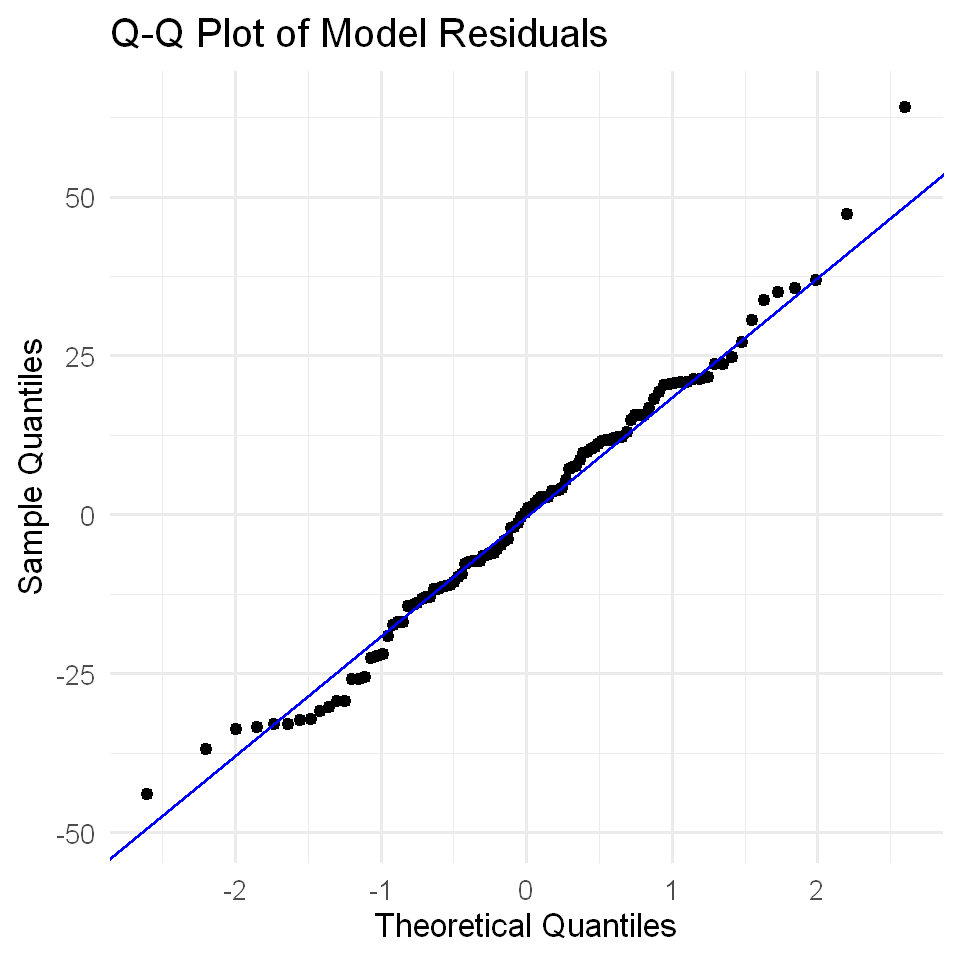

In [50]:
options(repr.plot.width=8, repr.plot.height=8)
res <- resid(f4)

ggplot(data = data.frame(residuals = res), aes(sample = residuals)) +
       stat_qq() +  # Q-Q points
       stat_qq_line(color = "blue") +  # Reference line
       theme_minimal(base_size=20) +
       labs(
            title = "Q-Q Plot of Model Residuals",
            x = "Theoretical Quantiles",
            y = "Sample Quantiles"
           )

## Visualize our model:

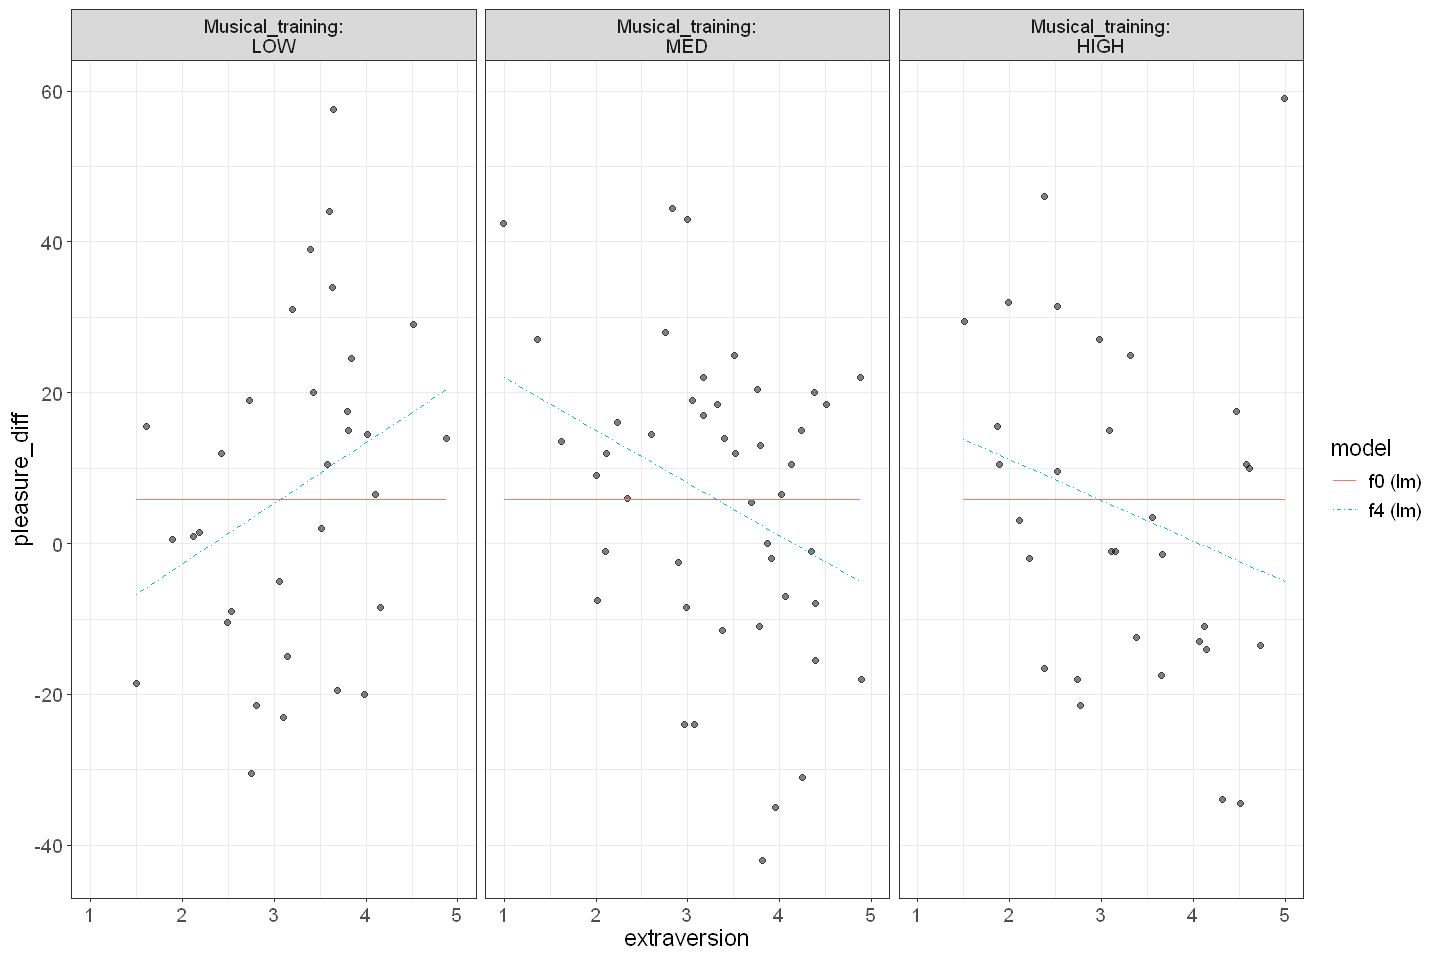

In [28]:
options(repr.plot.width=12, repr.plot.height=8)

compare.fits(pleasure_diff~extraversion | Musical_training, data=df_cleaned, f0,f4)

`geom_smooth()` using formula = 'y ~ x'


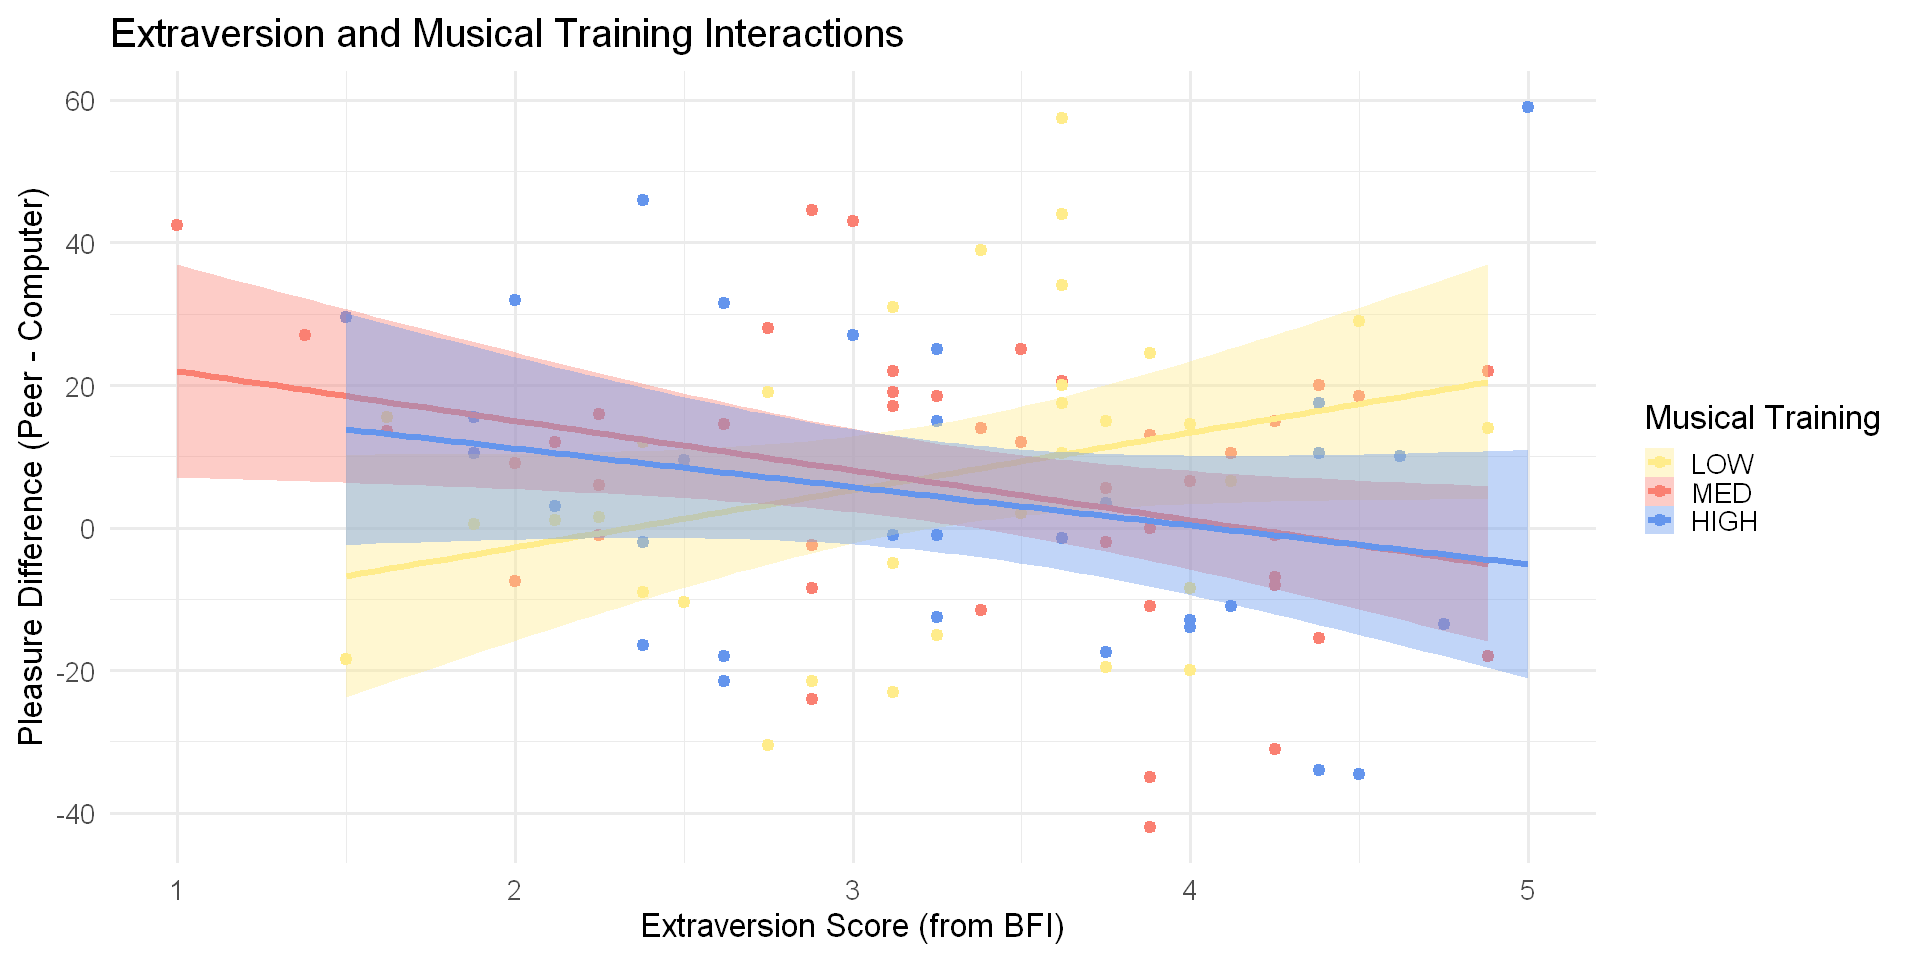

In [64]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(df_cleaned, aes(x=extraversion, y=pleasure_diff, fill=Musical_training, color=Musical_training)) +
       geom_point() +
       geom_smooth(method=glm) +
       scale_color_manual(values = c("LOW" = "lightgoldenrod1", "MED" = "salmon", "HIGH" = "cornflowerblue"), name="Musical Training") +
       scale_fill_manual(values = c("LOW" = "lightgoldenrod1", "MED" = "salmon", "HIGH" = "cornflowerblue"), name="Musical Training") +
       labs(x="Extraversion Score (from BFI)", 
            y="Pleasure Difference (Peer - Computer)",
            title="Extraversion and Musical Training Interactions") +
       theme_minimal(base_size=20)